#Link:

https://github.com/Jiaxuan-Peng/IS-4487/blob/main/Demos/demo_10_classification.ipynb

# **IS4487 Week 10 - Practice/Demo Code: Supervised Learning with Decision Trees**

This notebook is designed to help you follow along with the **Week 10 Lecture and Reading**, introducing you to Classification.

The practice code demos are intended to give you a chance to see working code and can be a source for your lap and assignment work.  Each section contains short explanations and annotated code that reflect the steps in the reading.

### Topics for this demo:
- Create a classification tree
- Visualize the tree output
- Evaluate a tree

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Demos/demo_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Context: Financial Services Marketing
We will use a classic UCI banking dataset.  Variables include:

| Feature     | Description                                          | Type        |
| ----------- | ---------------------------------------------------- | ----------- |
| `age`       | Age of the client                                    | Numeric     |
| `default`   | Has credit in default? (yes/no)                      | Categorical |
| `balance`   | Average yearly account balance in euros              | Numeric     |
| `housing`   | Has housing loan? (yes/no)                           | Categorical |
| `loan`      | Has personal loan? (yes/no)                          | Categorical |
| `y`         | Target: Subscribed to term deposit? (yes/no)         | Categorical |

Your task is to predict `y` whether a client will subscribe to a term deposit (yes/no) based on various attributes from a bank marketing campaign.  A term deposit is a fixed-timeframe investment like a CD or bond.

#**ML model: Classification Tree**

This is a decision tree used to predict a categorical outcome. This model will evaluate each feature to determine the best split and order to predict the target variable.

## **Step 1. Import libraries, load data and preview it**

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV

# Load dataset with a comma separator
url = "https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/bank_subscription.csv"
df = pd.read_csv(url, sep=',')

In [64]:
# Preview the data
display(df.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,69,self-employed,divorced,secondary,no,20406,no,no,telephone,16,apr,350,7,148,7,unknown,yes
1,32,self-employed,single,secondary,no,49190,yes,no,cellular,19,jun,588,5,138,1,other,no
2,89,services,single,secondary,no,45284,yes,no,cellular,15,feb,789,3,291,2,unknown,no
3,78,unemployed,divorced,secondary,yes,43200,no,no,cellular,25,apr,263,5,117,3,unknown,no
4,38,admin.,single,tertiary,no,49002,yes,no,unknown,30,jul,659,3,245,8,failure,yes


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4500 non-null   int64 
 1   job        4500 non-null   object
 2   marital    4500 non-null   object
 3   education  4500 non-null   object
 4   default    4500 non-null   object
 5   balance    4500 non-null   int64 
 6   housing    4500 non-null   object
 7   loan       4500 non-null   object
 8   contact    4500 non-null   object
 9   day        4500 non-null   int64 
 10  month      4500 non-null   object
 11  duration   4500 non-null   int64 
 12  campaign   4500 non-null   int64 
 13  pdays      4500 non-null   int64 
 14  previous   4500 non-null   int64 
 15  poutcome   4500 non-null   object
 16  y          4500 non-null   object
dtypes: int64(7), object(10)
memory usage: 597.8+ KB


In [66]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,53.304444,23745.860444,15.486444,509.410222,5.030889,200.973778,4.378667
std,20.690970,15018.833165,8.659884,283.098139,2.567199,115.695659,2.859251
min,18.000000,-1992.000000,1.000000,30.000000,1.000000,-1.000000,0.000000
25%,35.000000,10730.500000,8.000000,261.000000,3.000000,100.750000,2.000000
50%,53.000000,23253.000000,16.000000,504.000000,5.000000,205.000000,4.000000
75%,71.000000,36874.000000,23.000000,760.000000,7.000000,299.000000,7.000000
max,89.000000,49998.000000,30.000000,999.000000,9.000000,399.000000,9.000000


# Any observations?

In [67]:
mappings = {}

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')
    mappings[col] = dict(enumerate(df[col].cat.categories))

    # apply encoding
    df[col] = df[col].cat.codes

mappings

{'job': {0: 'admin.',
  1: 'blue-collar',
  2: 'entrepreneur',
  3: 'housemaid',
  4: 'management',
  5: 'retired',
  6: 'self-employed',
  7: 'services',
  8: 'student',
  9: 'technician',
  10: 'unemployed'},
 'marital': {0: 'divorced', 1: 'married', 2: 'single'},
 'education': {0: 'primary', 1: 'secondary', 2: 'tertiary'},
 'default': {0: 'no', 1: 'yes'},
 'housing': {0: 'no', 1: 'yes'},
 'loan': {0: 'no', 1: 'yes'},
 'contact': {0: 'cellular', 1: 'telephone', 2: 'unknown'},
 'month': {0: 'apr',
  1: 'aug',
  2: 'dec',
  3: 'feb',
  4: 'jan',
  5: 'jul',
  6: 'jun',
  7: 'mar',
  8: 'may',
  9: 'nov',
  10: 'oct',
  11: 'sep'},
 'poutcome': {0: 'failure', 1: 'other', 2: 'success', 3: 'unknown'},
 'y': {0: 'no', 1: 'yes'}}

In [68]:
df.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,53.304444,5.026444,0.992667,1.009778,0.092000,23745.860444,0.584889,0.200444,0.404444,15.486444,5.398000,509.410222,5.030889,200.973778,4.378667,1.504222,0.500000
std,20.690970,3.166417,0.807384,0.811888,0.289058,15018.833165,0.492796,0.400377,0.669720,8.659884,3.464685,283.098139,2.567199,115.695659,2.859251,1.131587,0.500056
min,18.000000,0.000000,0.000000,0.000000,0.000000,-1992.000000,0.000000,0.000000,0.000000,1.000000,0.000000,30.000000,1.000000,-1.000000,0.000000,0.000000,0.000000
25%,35.000000,2.000000,0.000000,0.000000,0.000000,10730.500000,0.000000,0.000000,0.000000,8.000000,2.000000,261.000000,3.000000,100.750000,2.000000,0.000000,0.000000
50%,53.000000,5.000000,1.000000,1.000000,0.000000,23253.000000,1.000000,0.000000,0.000000,16.000000,5.000000,504.000000,5.000000,205.000000,4.000000,2.000000,0.500000
75%,71.000000,8.000000,2.000000,2.000000,0.000000,36874.000000,1.000000,0.000000,1.000000,23.000000,8.000000,760.000000,7.000000,299.000000,7.000000,3.000000,1.000000
max,89.000000,10.000000,2.000000,2.000000,1.000000,49998.000000,1.000000,1.000000,2.000000,30.000000,11.000000,999.000000,9.000000,399.000000,9.000000,3.000000,1.000000


# Check for missing values, outliers, and duplicate records


In [69]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [70]:
print(df.duplicated().sum())

0


In [71]:
df = df[df['balance']>0]
df = df[df['pdays']>0]

In [72]:
df.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000
mean,53.174960,5.036103,0.991206,1.011109,0.090720,24616.177505,0.582735,0.200879,0.404767,15.490396,5.396667,510.288359,5.031011,201.947234,4.377227,1.509373,0.500347
std,20.689233,3.164560,0.807039,0.811872,0.287243,14518.384098,0.493164,0.400704,0.669968,8.655172,3.461431,283.520558,2.568048,114.871101,2.857216,1.131194,0.500058
min,18.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,35.000000,2.000000,0.000000,0.000000,0.000000,11792.000000,0.000000,0.000000,0.000000,8.000000,2.000000,262.000000,3.000000,102.000000,2.000000,0.000000,0.000000
50%,53.000000,5.000000,1.000000,1.000000,0.000000,24238.000000,1.000000,0.000000,0.000000,16.000000,5.000000,506.000000,5.000000,205.000000,4.000000,2.000000,1.000000
75%,71.000000,8.000000,2.000000,2.000000,0.000000,37374.000000,1.000000,0.000000,1.000000,23.000000,8.000000,762.000000,7.000000,299.000000,7.000000,3.000000,1.000000
max,89.000000,10.000000,2.000000,2.000000,1.000000,49998.000000,1.000000,1.000000,2.000000,30.000000,11.000000,999.000000,9.000000,399.000000,9.000000,3.000000,1.000000


# How many yes and no?


In [73]:
df['y'].value_counts()

,count
y,
1,2162
0,2159


## **Step 2: Prepare Data**

Theoretically decision trees are able to handle both continuous and categorical inputs. However Python's version of Decision Trees cannot and requires us to convert catgeorical outcomes into numeric features using One-hot-Encoding or other encoding.

We will choose a subset of the columns to build our tree.

We will have to replace our binary features into 0/1.

In [74]:
# Columns to use
features = df.drop('y', axis=1).columns.tolist()
target = 'y'

# Features and label
X = df[features]
y = df[target]

X.shape, y.shape

((4321, 16), (4321,))

## **Step 3: Split Dataset into Training and Testing**

We will use a built-in function from the `sklearn.model_selection` package (see import statements called `train_test_split()`.

This has a parameter `random_state` - this is needed to initialize randomization. Many ML algorithms start by first randomly setting parameter values (that they are estimating in order to do their task). random_state here decides how to pick random samples to be in train or test.

Setting  ensures reproducibility by setting a *seed* for the internal random number generator, which controls choices like which features to consider at each split when multiple options are equally good. This guarantees that running the same algorithm with the same random_state will produce the exact same tree structure and results, which is crucial for debugging, comparing models, and validating experiments.

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
# Train/test split - 70-30
# Notice it produces 4 sub-datasets, 2 for X and corresponding two for y

# Ensure y_train is of integer type for the classifier
# y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Step 4: Create and Fit Model**

In the first step, we initialize a new Decision Tree. There are many things that you can customize - if you dont specify a parameter, it will use its default values.
- criterion: the purity measure to use. The default is *gini impurity*, we can change it by setting it to *entropy* to use **Information Gain**.
- max_depth: how deep a branch can be.
- random_state sets the random seed for tree building


Calling the method `DecisionTreeClassifier.fit()` will run the model, build the tree, choose the best features etc.

In [77]:
# Intialize decision tree
clf = DecisionTreeClassifier(criterion = 'entropy', max_depth=4, random_state=42)

# Train the model on X and y in the training data
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

Entropy → measures impurity

Information Gain → reduction in entropy after a split

Information Gain =
Entropy(parent)
−
Weighted Entropy(children)
Information Gain=Entropy(parent)−Weighted Entropy(children)

## **Step 5: Create Visualization to View the Tree**

Notice: the tree is only 4 branches deep (since we set max_depth = 4).

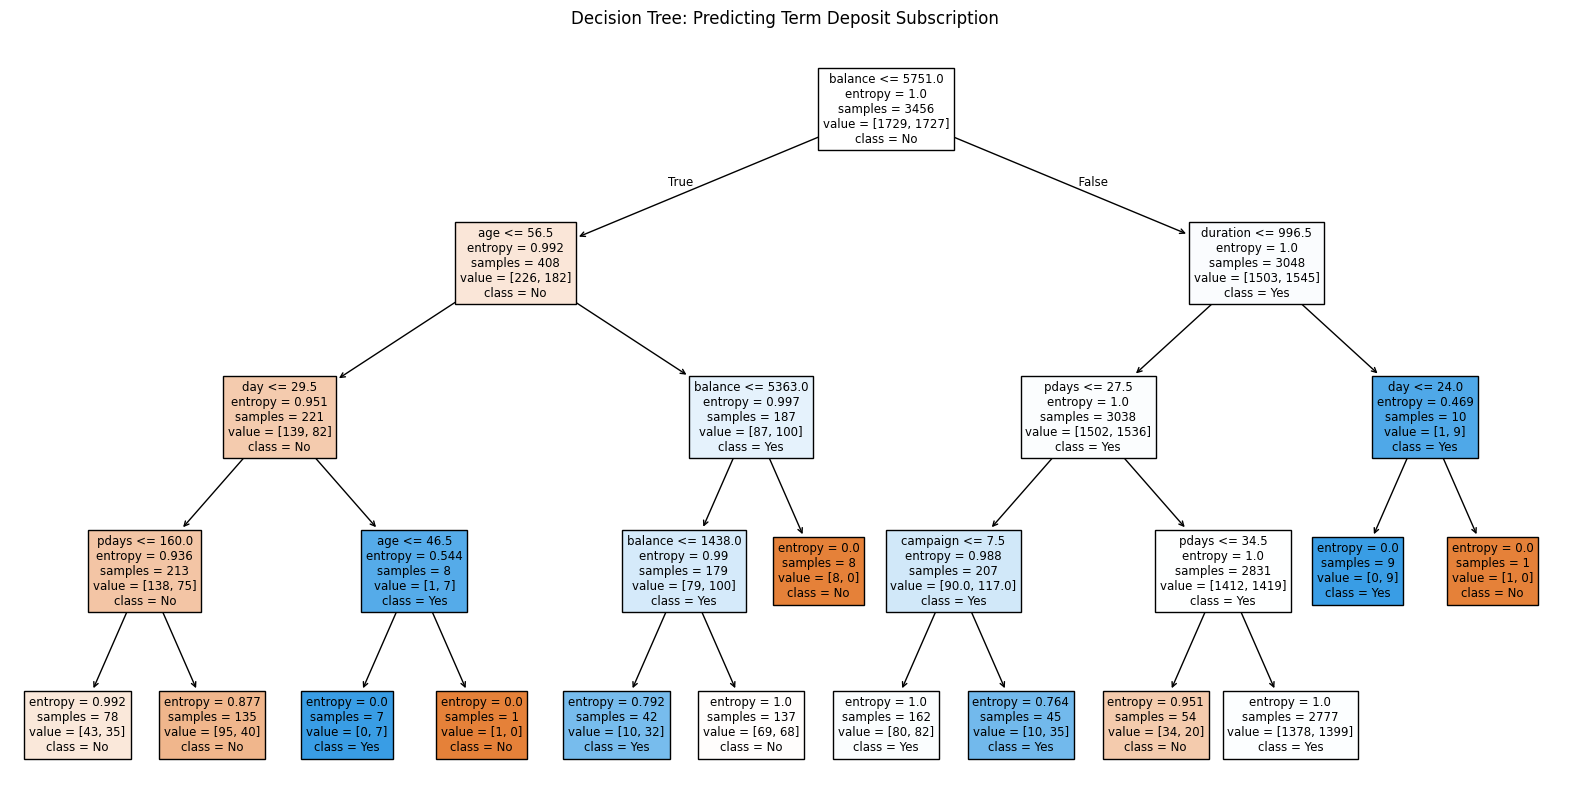

In [78]:
# Plot decision tree
plt.figure(figsize=(20, 10))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=["No", "Yes"])
plt.title("Decision Tree: Predicting Term Deposit Subscription")
plt.show()

# Before evaluation, do you think this model performs well (Check the entropy at the leaf nodes)?

If most leaf nodes have low entropy, the model is likely good.

If many leaves still have high entropy, the model is likely underperforming or too shallow.

## **Step 6: Evaluate the Tree**

Let us evaluate the model using the standard **metrics for classification**: Accuracy, Precision, Recall and F1-score for ***both training data and testing data***.

Generally, we only need to evaluate on testing data, but we will do both to understand **overfitting** and **underfitting**


In [79]:
#### TRAINING DATA PERFORMANCE #####

# Make predictions on the training set - how well does the model predict the training data for which we have ground truth labels
y_train_pred = clf.predict(X_train)

# Calculate evaluation metrics for training data
accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)
cm = confusion_matrix(y_train, y_train_pred)
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"])

print("How did the model do on the training data?")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print("\nConfusion Matrix:")
print(cm_df)

#### MODEL EVALUATION - TESTING DATA PERFORMANCE #####

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Calculate evaluation metrics for testing data
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"])

print("\n\nMODEL EVALUATION: How did the model do on the test data? ")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print("\nConfusion Matrix:")
print(cm_df)

How did the model do on the training data?
Accuracy: 0.53
Precision: 0.51
Recall: 0.91
F1-score: 0.66

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0          251         1478
Actual 1          163         1564


MODEL EVALUATION: How did the model do on the test data? 
Accuracy: 0.51
Precision: 0.51
Recall: 0.88
F1-score: 0.64

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0           57          373
Actual 1           54          381


# What are TP, FP, TN, FN?

The positive class (1) is the outcome you care most about detecting.
Definitions

TP (True Positive)
Model predicts 1, and actual is 1
→ Correctly predicted positive

FP (False Positive)
Model predicts 1, but actual is 0
→ Incorrectly predicted positive (false alarm)

TN (True Negative)
Model predicts 0, and actual is 0
→ Correctly predicted negative

FN (False Negative)
Model predicts 0, but actual is 1
→ Missed a positive case

TP = 381

FP = 373

TN = 57

FN = 54

# How to compute Precision and Recall accoridng to confusion matrix


Precision = how many predicted positives are correct

Recall = how many actual positives are captured

precision = TP / (TP + FP) = 381 /(381+373) = 0.51


recall = TP / (TP + FN) = 381/(381+54) = 0.88

In [80]:
# Let us print the actual and true max depth of the tree

print(f"The max_depth of the model is: {clf.get_params()['max_depth']}")
print(f"The actual depth of the tree in clf is: {clf.tree_.max_depth}")

The max_depth of the model is: 4
The actual depth of the tree in clf is: 4


### **UNDERFITTING**

Notice that our above tree does not perform well on the training data (F1-score = 0.53). Unsurprisingly, it also does not do well on the test data. We had restricted the tree to be of max depth 4.

This is a class case of **'UNDERFITTING'**

What if we remove this restriction? Let's see what happens.

## **Step 7: Compare with another tree by changing parameters**

### 7a. Try a tree with no max_depth restriction

In [87]:
#initialize a second tree - no max_depth is specified
clf = DecisionTreeClassifier(criterion = 'entropy',  random_state=42)

# Train the model on X and y in the training data
clf.fit(X_train, y_train)

#### TRAINING DATA PERFORMANCE #####

# Make predictions on the training set
y_train_pred = clf.predict(X_train)

# Calculate evaluation metrics
accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)

print("How did the model do on the training data?")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

#### MODEL EVALUATION - TESTING DATA PERFORMANCE #####

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n\nHow did the model do on the test data? EVALUATION")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

How did the model do on the training data?
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-score: 1.00


How did the model do on the test data? EVALUATION
Accuracy: 0.49
Precision: 0.49
Recall: 0.45
F1-score: 0.47


In [82]:
print(f"The max_depth of the model is: {clf.get_params()['max_depth']}")
print(f"The actual depth of the tree in clf is: {clf.tree_.max_depth}")

The max_depth of the model is: None
The actual depth of the tree in clf is: 40


### **OVERFITTING**

**Now, what did you notice about model performance?**

The model now perfectly predicts in the training data (accuracy = 100%, F1-Score - 1.0), but continues to perform poorly in the test data (F1-score = 0.50 (compared to 0.53 before)). In fact the performance in the test data is even worse now.

This is a classic case of **'OVERFITTING'**.

The model is so deep so it perfectly predicts in training data, but is learning noise, and true underlying associations, so it does **not generalize** well to test data.


### 7b. Try a tree with different parameters

In [83]:

# Define the parameter grid to search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(1, 21) # Test max_depth from 1 to 20
}

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
# We use 'f1' as the scoring metric because the target classes are balanced.
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1-score found: {grid_search.best_score_:.2f}")

# Update the best_model with the best estimator found by GridSearchCV
best_model = grid_search.best_estimator_

print("\nEvaluating the best model found by Grid Search on training data:")
y_train_pred_gs = best_model.predict(X_train)
accuracy_train_gs = accuracy_score(y_train, y_train_pred_gs)
f1_train_gs = f1_score(y_train, y_train_pred_gs)
print(f"Training Accuracy: {accuracy_train_gs:.2f}")
print(f"Training F1-score: {f1_train_gs:.2f}")

print("\nEvaluating the best model found by Grid Search on test data:")
y_pred_gs = best_model.predict(X_test)
accuracy_test_gs = accuracy_score(y_test, y_pred_gs)
f1_test_gs = f1_score(y_test, y_pred_gs)
print(f"Test Accuracy: {accuracy_test_gs:.2f}")
print(f"Test F1-score: {f1_test_gs:.2f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters found: {'criterion': 'entropy', 'max_depth': 2}
Best F1-score found: 0.62

Evaluating the best model found by Grid Search on training data:
Training Accuracy: 0.52
Training F1-score: 0.66

Evaluating the best model found by Grid Search on test data:
Test Accuracy: 0.51
Test F1-score: 0.66


In [84]:
# Initialize, and train/fit a new model
best_model = DecisionTreeClassifier(criterion = 'entropy', max_depth=2, random_state=42)
best_model.fit(X_train, y_train)

#### TRAINING DATA PERFORMANCE #####

# Make predictions on the training set
y_train_pred = best_model.predict(X_train)

# Calculate evaluation metrics
accuracy = accuracy_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)

print("How did the model do on the training data?")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-score: {f1:.2f}")


#### MODEL EVALUATION - TESTING DATA PERFORMANCE #####

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n\nHow did the model do on the test data? EVALUATION")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-score: {f1:.2f}")

How did the model do on the training data?
Accuracy: 0.52
F1-score: 0.66


How did the model do on the test data? EVALUATION
Accuracy: 0.51
F1-score: 0.66


## **Step 8. Assess feature importances of the best model**

The output suggests that `balance` followed by `age` were the most important in predicting the target.

In [85]:
print("Feature importances for best_model (max_depth=5):")
sorted_importance_clf = sorted(zip(X.columns, best_model.feature_importances_), key=lambda x: x[1], reverse=True)
for name, importance in sorted_importance_clf:
    print(f"{name}: {importance:.4f}")

Feature importances for best_model (max_depth=5):
age: 0.4686
duration: 0.3046
balance: 0.2268
job: 0.0000
marital: 0.0000
education: 0.0000
default: 0.0000
housing: 0.0000
loan: 0.0000
contact: 0.0000
day: 0.0000
month: 0.0000
campaign: 0.0000
pdays: 0.0000
previous: 0.0000
poutcome: 0.0000


#**ML model: Ensemble methods - Random Forest**

## **Step 9: Try an ensemble model**

Let us try a Bagging Model with Trees for classification, called a Random Forest Classifier.

In [86]:
#ensemble model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(criterion = 'entropy', n_estimators = 15, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Make predictions on the training set
y_train_pred = rf.predict(X_train)

# Calculate evaluation metrics
accuracy = accuracy_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)

print("How did the model do on the training data?")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-score: {f1:.2f}")


# Make predictions on the test set
y_pred = rf.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n\nHow did the model do on the test data? EVALUATION")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-score: {f1:.2f}")

How did the model do on the training data?
Accuracy: 0.65
F1-score: 0.68


How did the model do on the test data? EVALUATION
Accuracy: 0.49
F1-score: 0.53


## Summary:

### Insights or Next Steps

*   Sometimes the models we run will not give us very good results, like the current model.
what can do next?
* Often the problem lies in the features. They are likely not the best set. You can run a correlation matrix to determine if there are better features. Then re-run the model.
* Do more feature engineering to create better features
* You can try a different ML model for classification.

